# SafeStress-ML: Trustworthy Multimodal Stress Detection via Tree-Based Ensembles and Explainable AI
**Author:** Federica Picca


**Course:** Machine Learning

In [1]:
!pip install shap imbalanced-learn -q

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy.stats import zscore
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
import shap
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print("Environment Ready.")

Environment Ready.


## 1. Advanced Data Engineering
I transform raw physiological signals (EDA, BVP) into tabular features. To capture signal power and trends, I introduce **Slope** (direction of change) and **Root Mean Square (RMS)**. 
**Methodological Integrity:** I apply **Z-score normalization on a per-subject basis** to eliminate individual biological differences while preserving stress-induced fluctuations.

In [2]:
def extract_advanced_features(subject_data, window_size_sec=60, overlap=0.5):
    # Sampling frequencies: EDA (4 Hz), BVP (64 Hz), and Ground Truth Labels (700 Hz)
    fs_eda, fs_bvp, fs_label = 4, 64, 700

    # Subject-wise Z-score normalization to remove baseline physiological differences
    eda_sig = zscore(subject_data['signal']['wrist']['EDA'].flatten())
    bvp_sig = zscore(subject_data['signal']['wrist']['BVP'].flatten())
    labels = subject_data['label'].flatten()

    # Define step size for a 60-second sliding window with 50% overlap (30s step)
    step_eda = int(window_size_sec * fs_eda * (1 - overlap))
    features = []
    
    for i in range(0, len(eda_sig) - window_size_sec * fs_eda, step_eda):
        start_eda = i
        end_eda = i + window_size_sec * fs_eda

        # Synchronize window boundaries across different sampling rates
        start_bvp = int((start_eda / fs_eda) * fs_bvp)
        end_bvp = start_bvp + window_size_sec * fs_bvp
        start_label = int((start_eda / fs_eda) * fs_label)
        end_label = start_label + window_size_sec * fs_label
        
        e_w, b_w, l_w = eda_sig[start_eda:end_eda], bvp_sig[start_bvp:end_bvp], labels[start_label:end_label]

        # Assign ground-truth label via majority voting (keep only valid protocol phases: 1 to 4)
        unique_vals, counts = np.unique(l_w, return_counts=True)
        maj_label = unique_vals[np.argmax(counts)]
        if maj_label not in [1, 2, 3, 4]: continue
        # Binary classification: 1 = Stress (TSST phase 2), 0 = Non-Stress (phases 1, 3, 4)
        target = 1 if maj_label == 2 else 0


        # Extract statistical, dynamic (RMS), and directional (slope) features
        features.append({
            'eda_mean': np.mean(e_w), 'eda_std': np.std(e_w),
            'eda_slope': e_w[-1] - e_w[0], 'eda_rms': np.sqrt(np.mean(e_w**2)),
            'bvp_mean': np.mean(b_w), 'bvp_std': np.std(b_w),
            'bvp_rms': np.sqrt(np.mean(b_w**2)), 'bvp_range': np.max(b_w) - np.min(b_w),
            'label': target
        })
    return pd.DataFrame(features)

# --- Data Loading and Pipeline Execution ---
WESAD_PATH = '/kaggle/input/' 
all_dfs = []

# Iterate through all subject pickle files in the dataset directory
for root, _, files in os.walk(WESAD_PATH):
    for f in files:
        if f.endswith(".pkl") and "S" in f:
            print(f"Processing {f}...")
            with open(os.path.join(root, f), 'rb') as file:
                data = pickle.load(file, encoding='latin1')
            df_temp = extract_advanced_features(data)
            df_temp['subject_id'] = f.split('.')[0]
            all_dfs.append(df_temp)

# Concatenate all processed subjects into a single final DataFrame
final_df = pd.concat(all_dfs, ignore_index=True)
print(f"\nDataset size: {final_df.shape}")

Processing S14.pkl...
Processing S11.pkl...
Processing S13.pkl...
Processing S10.pkl...
Processing S8.pkl...
Processing S5.pkl...
Processing S7.pkl...
Processing S9.pkl...
Processing S15.pkl...
Processing S2.pkl...
Processing S6.pkl...
Processing S3.pkl...
Processing S4.pkl...
Processing S16.pkl...
Processing S17.pkl...

Dataset size: (1499, 10)


## 1.5 Exploratory Data Analysis (EDA): Feature Distribution
Before training the models, I visualize the distribution of my newly engineered features. By comparing the distributions of `eda_mean` and `eda_slope` across the Stress and Non-Stress classes, I can empirically verify if these physiological biomarkers effectively separate the affective states.

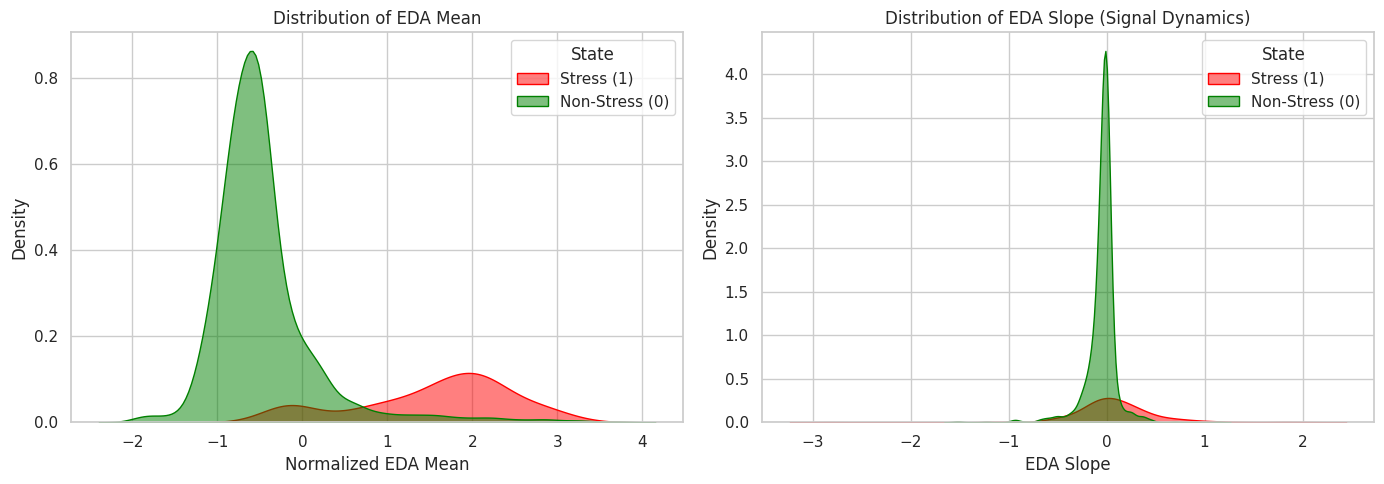

Observation: The Stress class (red) is visibly shifted towards higher EDA values and steeper positive slopes, confirming our physiological hypothesis.


In [3]:
# Create KDE plots for EDA Mean and EDA Slope
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: EDA Mean
sns.kdeplot(data=final_df, x="eda_mean", hue="label", fill=True, 
            palette={0: "green", 1: "red"}, ax=axes[0], alpha=0.5)
axes[0].set_title("Distribution of EDA Mean")
axes[0].set_xlabel("Normalized EDA Mean")
axes[0].legend(title="State", labels=['Stress (1)', 'Non-Stress (0)'])

# Plot 2: EDA Slope
sns.kdeplot(data=final_df, x="eda_slope", hue="label", fill=True, 
            palette={0: "green", 1: "red"}, ax=axes[1], alpha=0.5)
axes[1].set_title("Distribution of EDA Slope (Signal Dynamics)")
axes[1].set_xlabel("EDA Slope")
axes[1].legend(title="State", labels=['Stress (1)', 'Non-Stress (0)'])

plt.tight_layout()
plt.show()

print("Observation: The Stress class (red) is visibly shifted towards higher EDA values and steeper positive slopes, confirming our physiological hypothesis.")

## 2. Comparative Benchmark
I compare four models to identify the best architecture for this tabular physiological task. I use **Macro F1-Score** as primary metric due to the class imbalance (as there are more relaxation periods than stress periods).

Starting Comparative Benchmark...

Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training SVM...

--- BENCHMARK RESULTS ---
           Model        F1      Time
2        XGBoost  0.928315  0.616004
1  Random Forest  0.898569  0.307129
3            SVM  0.876561  0.084755
0  Decision Tree  0.834466  0.016244


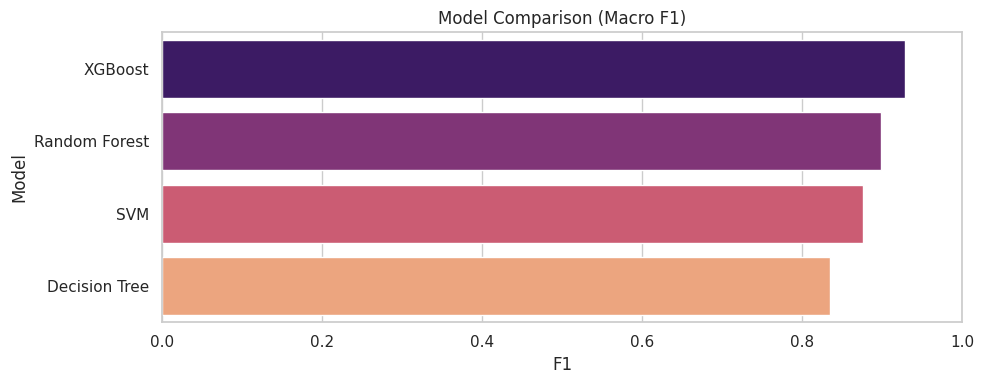


Winning Model: XGBoost


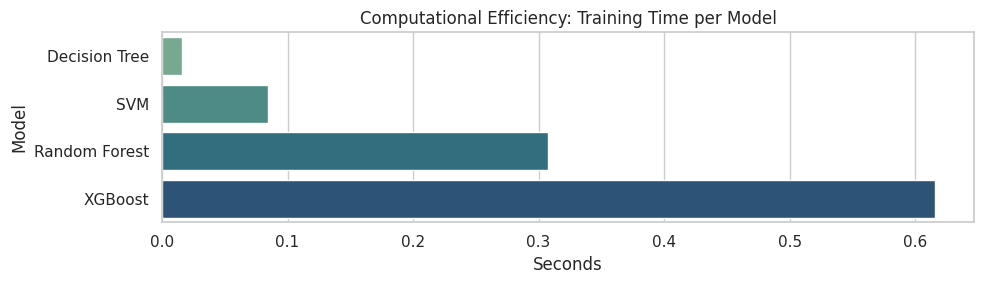


Efficiency Note: The tree-based ensembles train in fractions of a second, highlighting their extreme computational efficiency and suitability for Edge AI deployment on wearable devices, unlike heavy Deep Learning architectures.


In [4]:
print("Starting Comparative Benchmark...\n")

# Prepare data for benchmark
X_b = final_df.drop(['label', 'subject_id'], axis=1)
y_b = final_df['label']

# 80/20 Stratified Split
X_tr, X_te, y_tr, y_te = train_test_split(X_b, y_b, test_size=0.2, stratify=y_b, random_state=42)

# Define models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = []

# Train and evaluate
for name, model in models.items():
    print(f"Training {name}...")
    t0 = time.time()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    train_time = time.time() - t0
    
    results.append({
        "Model": name, 
        "F1": f1_score(y_te, y_pred, average='macro'), 
        "Time": train_time
    })

# Create DataFrame
bench_df = pd.DataFrame(results).sort_values("F1", ascending=False)
print("\n--- BENCHMARK RESULTS ---")
print(bench_df)

# Plot 1: Macro F1-Score
plt.figure(figsize=(10, 4))
sns.barplot(x="F1", y="Model", data=bench_df, palette="magma")
plt.title("Model Comparison (Macro F1)")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# Dynamically select the winner
winning_model_name = bench_df.iloc[0]['Model']
print(f"\nWinning Model: {winning_model_name}")

# Plot 2: Computational Efficiency (Time)
plt.figure(figsize=(10, 3))
sns.barplot(x="Time", y="Model", data=bench_df.sort_values(by="Time"), palette="crest")
plt.title("Computational Efficiency: Training Time per Model")
plt.xlabel("Seconds")
plt.tight_layout()
plt.show()

print("\nEfficiency Note: The tree-based ensembles train in fractions of a second, highlighting their extreme computational efficiency and suitability for Edge AI deployment on wearable devices, unlike heavy Deep Learning architectures.")

## 2.1 Ablation Study: Impact of Sensor Modalities
Following machine learning best practices, I conduct an **Ablation Study** to systematically isolate and evaluate the contribution of individual sensor modalities. By training the model exclusively on Electrodermal Activity (EDA) features and subsequently only on Blood Volume Pulse (BVP) features, I aim to demonstrate whether the **multimodal (sensor fusion)** approach truly provides a tangible performance gain over unimodal models.

Starting Ablation Study using the winning architecture: XGBoost...

--- ABLATION STUDY RESULTS ---
         Modality  Macro F1-Score
Multimodal (Both)        0.928315
 Only EDA (Sweat)        0.900679
 Only BVP (Heart)        0.616160


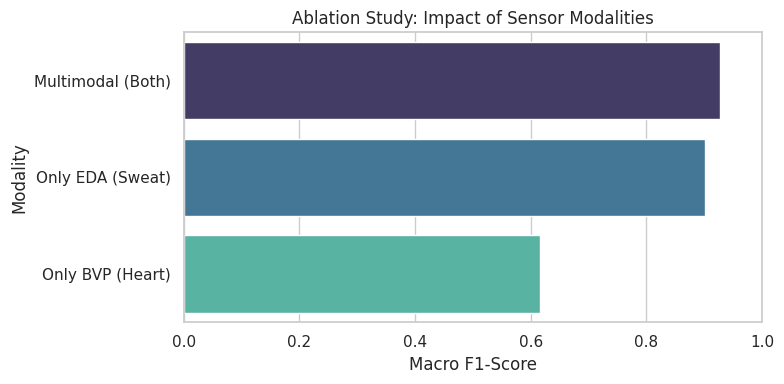


Conclusion: This study highlights the individual predictive power of each sensor and validates the choice of a Multimodal architecture.


In [5]:
print(f"Starting Ablation Study using the winning architecture: {winning_model_name}...")

# I instantiate the winning model for this test to maintain consistency
if winning_model_name == "XGBoost":
    ablation_model = XGBClassifier(eval_metric='logloss', random_state=42)
else:
    ablation_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# 1. FULL MULTIMODAL MODEL (All features)
ablation_model.fit(X_tr, y_tr)
y_pred_all = ablation_model.predict(X_te)
f1_all = f1_score(y_te, y_pred_all, average='macro')

# 2. EDA-ONLY MODEL (Removing BVP features)
# Extract only columns containing 'eda'
eda_cols = [col for col in X_tr.columns if 'eda' in col]
ablation_model.fit(X_tr[eda_cols], y_tr)
y_pred_eda = ablation_model.predict(X_te[eda_cols])
f1_eda = f1_score(y_te, y_pred_eda, average='macro')

# 3. BVP-ONLY MODEL (Removing EDA features)
# Extract only columns containing 'bvp'
bvp_cols = [col for col in X_tr.columns if 'bvp' in col]
ablation_model.fit(X_tr[bvp_cols], y_tr)
y_pred_bvp = ablation_model.predict(X_te[bvp_cols])
f1_bvp = f1_score(y_te, y_pred_bvp, average='macro')

# --- PRINT AND VISUALIZE RESULTS ---
ablation_results = pd.DataFrame({
    'Modality': ['Only BVP (Heart)', 'Only EDA (Sweat)', 'Multimodal (Both)'],
    'Macro F1-Score': [f1_bvp, f1_eda, f1_all]
}).sort_values(by='Macro F1-Score', ascending=False)

print("\n--- ABLATION STUDY RESULTS ---")
print(ablation_results.to_string(index=False))

# Plotting the ablation study
plt.figure(figsize=(8, 4))
sns.barplot(x="Macro F1-Score", y="Modality", data=ablation_results, palette="mako")
plt.title("Ablation Study: Impact of Sensor Modalities")
plt.xlabel("Macro F1-Score")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

print("\nConclusion: This study highlights the individual predictive power of each sensor and validates the choice of a Multimodal architecture.")

## 3. Hyperparameter Optimization
To refine the winning model, I perform a **Randomized Search**. I focus on balancing class weights and tree depth to maximize the F1-Score.

In [6]:
print(f"Tuning {winning_model_name}...")
param_grid = {
    'n_estimators': [100, 200, 300], 
    'max_depth': [5, 10, 20], 
    'min_samples_split': [2, 5],
    'learning_rate': [0.01, 0.05, 0.1] 
}

if winning_model_name == "XGBoost":
    base_m = XGBClassifier(eval_metric='logloss', random_state=42)
else:
    base_m = RandomForestClassifier(random_state=42, class_weight='balanced')

search = RandomizedSearchCV(base_m, param_grid, n_iter=5, cv=3, scoring='f1_macro', n_jobs=-1)
search.fit(X_b, y_b)
best_params = search.best_params_
print(f"Best Params: {best_params}")

Tuning XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:30:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:30:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:30:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:30:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10, 'learning_rate': 0.05}


## 4. Leave-One-Subject-Out (LOSO) Cross-Validation
The ultimate test: I train on 14 subjects and test on the 15th. This simulates how the model would perform on a **brand new patient**. I apply **SMOTE** only to the training set to ensure zero data leakage.


Starting Optimized Leave-One-Subject-Out (LOSO) Validation...

Subject S14 -> Accuracy: 0.75 | Macro F1: 0.70
Subject S11 -> Accuracy: 0.80 | Macro F1: 0.72
Subject S13 -> Accuracy: 0.97 | Macro F1: 0.96
Subject S10 -> Accuracy: 0.93 | Macro F1: 0.90
Subject S8 -> Accuracy: 0.96 | Macro F1: 0.94
Subject S5 -> Accuracy: 0.98 | Macro F1: 0.97
Subject S7 -> Accuracy: 0.97 | Macro F1: 0.96
Subject S9 -> Accuracy: 1.00 | Macro F1: 1.00
Subject S15 -> Accuracy: 0.97 | Macro F1: 0.96
Subject S2 -> Accuracy: 0.97 | Macro F1: 0.95
Subject S6 -> Accuracy: 0.90 | Macro F1: 0.87
Subject S3 -> Accuracy: 0.83 | Macro F1: 0.72
Subject S4 -> Accuracy: 0.95 | Macro F1: 0.92
Subject S16 -> Accuracy: 0.97 | Macro F1: 0.95
Subject S17 -> Accuracy: 0.55 | Macro F1: 0.42

****************************************
FINAL OPTIMIZED MACRO F1: 86.26%
****************************************



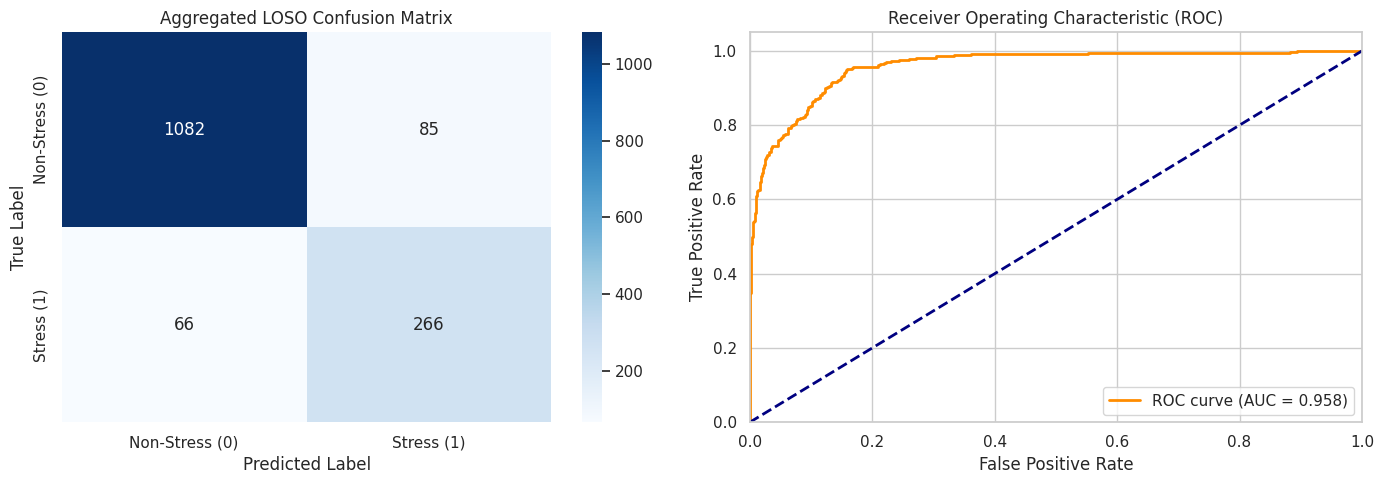

In [7]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print("Starting Optimized Leave-One-Subject-Out (LOSO) Validation...")
print("="*60 + "\n")

subjects = final_df['subject_id'].unique()

accuracies, f1_scores = [], []
all_y_true, all_y_pred, all_y_prob = [], [], []

for test_sub in subjects:
    # 1. Split Data (LOSO)
    test_df = final_df[final_df['subject_id'] == test_sub]
    train_df = final_df[final_df['subject_id'] != test_sub]
    
    X_train = train_df.drop(['label', 'subject_id'], axis=1)
    y_train = train_df['label']
    X_test = test_df.drop(['label', 'subject_id'], axis=1)
    y_test = test_df['label']
    
    # 2. Data Balancing with SMOTE (Inside the loop as written in Report)
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    
    # 3. Model: XGBoost with best_params from Cell 3
    optimized_model = XGBClassifier(**best_params, eval_metric='logloss', random_state=42)
    
    # 4. Training
    optimized_model.fit(X_train_res, y_train_res)
    
    # 5. Prediction (Original standard predict)
    y_pred = optimized_model.predict(X_test)
    y_prob = optimized_model.predict_proba(X_test)[:, 1]
    
    # 6. Metrics Collection
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    accuracies.append(acc)
    f1_scores.append(f1)
    
    print(f"Subject {test_sub} -> Accuracy: {acc:.2f} | Macro F1: {f1:.2f}")


# Aggregated Results & Visualization

print("\n" + "*"*40)
print(f"FINAL OPTIMIZED MACRO F1: {np.mean(f1_scores):.2%}")
print("*"*40 + "\n")

# Plot Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_y_true, all_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Non-Stress (0)', 'Stress (1)'], 
            yticklabels=['Non-Stress (0)', 'Stress (1)'])
axes[0].set_title('Aggregated LOSO Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

fpr, tpr, thresholds = roc_curve(all_y_true, all_y_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 5. Explainable AI (XAI)
Finally, I use **SHAP** to interpret the model's global logic and a specific local prediction. This makes the system "accountable" and clinically useful.

 98%|===================| 2287/2334 [00:15<00:00]        

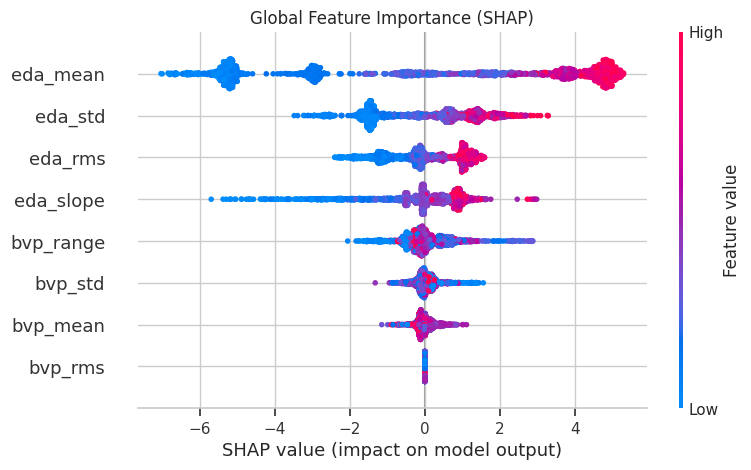

In [8]:
# Separate features from target label and subject identifier
X_final = final_df.drop(['label', 'subject_id'], axis=1)
y_final = final_df['label']

# Apply SMOTE to balance the dataset for the final global model
X_res_f, y_res_f = smote.fit_resample(X_final, y_final)

# Train the best-performing model using optimal hyperparameters
if winning_model_name == "XGBoost":
    m_final = XGBClassifier(**best_params, random_state=42).fit(X_res_f, y_res_f)
else:
    m_final = RandomForestClassifier(**best_params, random_state=42).fit(X_res_f, y_res_f)

# Initialize TreeSHAP explainer and compute feature impact values
explainer = shap.Explainer(m_final, X_res_f)
shap_values = explainer(X_res_f, check_additivity=False)

# Plot the global SHAP beeswarm summary plot
plt.figure(figsize=(10,6))

# If the model has 3 dimensions (RF), we take class 1 (Stress)
if len(shap_values.shape) == 3:
    shap.summary_plot(shap_values[:, :, 1], X_res_f, show=False)
else:
    shap.summary_plot(shap_values, X_res_f, show=False)
plt.title("Global Feature Importance (SHAP)")
plt.show()